# Alibaba Cluster Trace 2018 — LSTM / GRU / Ensemble 재학습

**실행 전:** 런타임 → 런타임 유형 변경 → **T4 GPU** 선택

파이프라인: 데이터 로드 → 전처리 → 학습 → `.keras` + `alibaba_scaler.pkl` 다운로드

## 0. GPU 확인

In [1]:
import tensorflow as tf
print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Alibaba 2018 데이터 로드

`datacentertracesdatasets` 패키지로 Alibaba 2018 machine_usage 원본(10초 단위)을 바로 불러옴.
컬럼: `cpu_util_percent`, `mem_util_percent`, `net_in`, `net_out`, `disk_io_percent`

In [2]:
!pip install datacentertracesdatasets -q

from datacentertracesdatasets import loadtraces
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('로드 중...')
df_raw = loadtraces.get_trace(
    trace_name='alibaba2018',
    trace_type='machine_usage',
    stride_seconds=10
)
print(f'완료: {len(df_raw):,}행')
print('컬럼:', df_raw.columns.tolist())
print(df_raw.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 14.1 MB/s eta 0:00:00
로드 중...
완료: 67,242행
컬럼: ['cpu_util_percent', 'mem_util_percent', 'net_in', 'net_out', 'disk_io_percent']
   cpu_util_percent  mem_util_percent     net_in    net_out  disk_io_percent
0         16.126977         87.138955  34.889051  27.657513         4.086727
1         21.587783         87.054299  34.909860  27.656439         4.042534
2         17.319328         86.949113  34.864683  27.626639         4.054622
3         16.828704         86.945370  34.886306  27.648935         4.062037
4         18.651835         86.949541  34.854940  27.614913         4.038991


## 2. 데이터 탐색 (EDA)

       cpu_util_percent  mem_util_percent        net_in       net_out  \
count      67242.000000      67242.000000  67242.000000  67242.000000   
mean          37.996305         88.007191     41.031254     32.524031   
std            9.854653          2.557804      3.765651      3.013827   
min           14.115328         77.589241     30.355000     21.990000   
25%           30.502849         86.295577     37.814145     29.993362   
50%           36.934843         88.196854     40.934006     32.464897   
75%           44.201066         89.804654     44.361275     35.199220   
max           79.848477         95.383117     47.513976     37.807771   

       disk_io_percent  
count     67242.000000  
mean          7.731480  
std           3.516245  
min           3.256186  
25%           5.268360  
50%           6.570700  
75%           9.169381  
max          31.620758  

총 67,242행 = 186.8시간 (10초 간격)


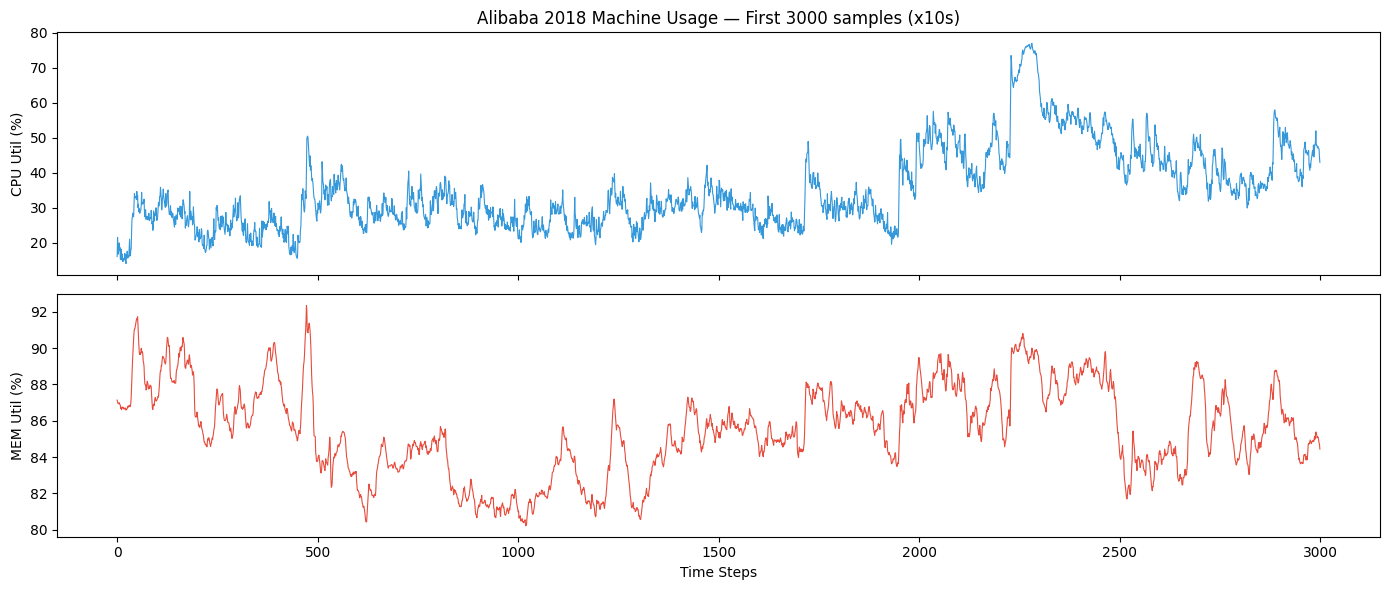

In [3]:
print(df_raw.describe())
print(f'\n총 {len(df_raw):,}행 = {len(df_raw)*10/3600:.1f}시간 (10초 간격)')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(df_raw['cpu_util_percent'].values[:3000], color='#3498db', linewidth=0.8)
axes[0].set_ylabel('CPU Util (%)')
axes[0].set_title('Alibaba 2018 Machine Usage — First 3000 samples (x10s)')
axes[1].plot(df_raw['mem_util_percent'].values[:3000], color='#e74c3c', linewidth=0.8)
axes[1].set_ylabel('MEM Util (%)')
axes[1].set_xlabel('Time Steps')
plt.tight_layout()
plt.savefig('alibaba_preview.png', dpi=150)
plt.show()

## 3. 전처리 (10초 → 1초 리샘플링, 3-피처 구성)

In [4]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# 3-1. 첫 72시간만 사용 (72h * 3600s / 10s = 25920 rows)
USE_ROWS = int(72 * 3600 / 10)
df_use = df_raw.iloc[:USE_ROWS].copy()
print(f'사용: {len(df_use):,}행 ({len(df_use)*10/3600:.1f}시간치)')

# 3-2. datetime 인덱스 부여
df_use = df_use.copy()
df_use.index = pd.date_range(start='2018-01-01', periods=len(df_use), freq='10s')

# 3-3. 10초 → 1초 리샘플링
print('리샘플링 중...')
resampled = df_use[['cpu_util_percent', 'mem_util_percent']].resample('1s').interpolate(method='linear')
resampled = resampled.ffill().bfill()
print(f'리샘플링 완료: {len(resampled):,}초')

# 3-4. 3-피처 구성 (ai_metrics_api.py 기존 구조 유지)
# User Count          <- mem_util_percent (메모리 = 동접 세션 대리 지표)
# Requests/s          <- cpu_util_percent (CPU = 요청 부하 대리 지표)
# Total Avg Resp Time <- cpu 기반 합성 (기존 kaggle 방식과 동일 로직)
resampled['user_count']    = resampled['mem_util_percent']
resampled['rps']           = resampled['cpu_util_percent']
resampled['response_time'] = 100.0 + (resampled['cpu_util_percent'] ** 1.5) * 0.5

features = resampled[['user_count', 'rps', 'response_time']]
print('피처 샘플:')
print(features.head(10))
print(features.describe())

사용: 25,920행 (72.0시간치)
리샘플링 중...
리샘플링 완료: 259,191초
피처 샘플:
                     user_count        rps  response_time
2018-01-01 00:00:00   87.138955  16.126977     132.381684
2018-01-01 00:00:01   87.130490  16.673057     134.040260
2018-01-01 00:00:02   87.122024  17.219138     135.726223
2018-01-01 00:00:03   87.113558  17.765218     137.439137
2018-01-01 00:00:04   87.105093  18.311299     139.178584
2018-01-01 00:00:05   87.096627  18.857380     140.944165
2018-01-01 00:00:06   87.088161  19.403460     142.735499
2018-01-01 00:00:07   87.079696  19.949541     144.552221
2018-01-01 00:00:08   87.071230  20.495622     146.393981
2018-01-01 00:00:09   87.062764  21.041702     148.260443
          user_count            rps  response_time
count  259191.000000  259191.000000  259191.000000
mean       86.429538      36.524327     212.972695
std         2.308319       9.280669      44.278859
min        79.553409      14.115328     126.515907
25%        84.875773      29.935844     181.894977

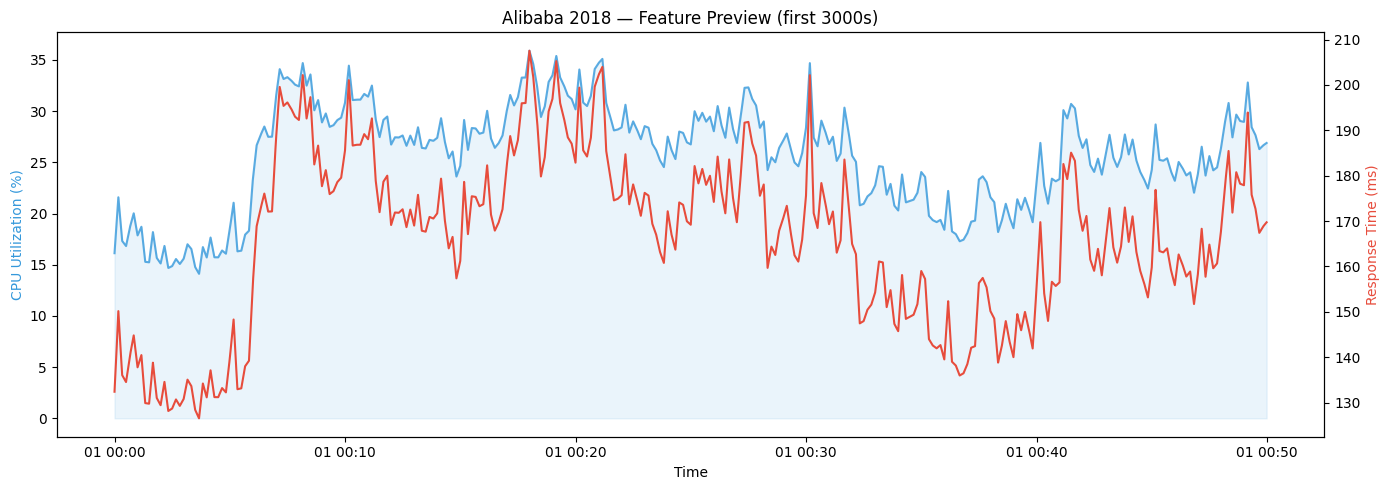

In [5]:
# 3-5. 시각화 (논문용)
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.plot(features.index[:3000], features['rps'][:3000], color='#3498db', alpha=0.8, label='CPU Util (RPS Proxy)')
ax1.fill_between(features.index[:3000], features['rps'][:3000], color='#3498db', alpha=0.1)
ax2.plot(features.index[:3000], features['response_time'][:3000], color='#e74c3c', linewidth=1.5, label='Latency (Synthesized)')
ax1.set_xlabel('Time')
ax1.set_ylabel('CPU Utilization (%)', color='#3498db')
ax2.set_ylabel('Response Time (ms)', color='#e74c3c')
plt.title('Alibaba 2018 — Feature Preview (first 3000s)')
fig.tight_layout()
plt.savefig('alibaba_feature_preview.png', dpi=150)
plt.show()

In [6]:
# 3-6. 정규화 & 시계열 윈도우 생성
LOOK_BACK = 60  # 과거 60초 → 다음 1초 예측

scaler = MinMaxScaler()
scaled = scaler.fit_transform(features.values)
joblib.dump(scaler, 'alibaba_scaler.pkl')
print('alibaba_scaler.pkl 저장 완료')

X, y = [], []
for i in range(len(scaled) - LOOK_BACK):
    X.append(scaled[i:i + LOOK_BACK, :])
    y.append(scaled[i + LOOK_BACK, 2])  # index 2 = response_time

X = np.array(X)
y = np.array(y)
print(f'X shape: {X.shape}')  # (samples, 60, 3)
print(f'y shape: {y.shape}')

split = int(len(X) * 0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]
print(f'Train: {len(X_train):,} / Val: {len(X_val):,}')

alibaba_scaler.pkl 저장 완료
X shape: (259131, 60, 3)
y shape: (259131,)
Train: 207,304 / Val: 51,827


## 4. 모델 학습

In [7]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Dense, Input, Average
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

INPUT_SHAPE = (LOOK_BACK, 3)
EPOCHS = 20
BATCH_SIZE = 512

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

def build_lstm(input_shape):
    model = Sequential([
        LSTM(64, activation='relu', input_shape=input_shape),
        Dense(1)
    ], name='lstm')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(64, activation='relu', input_shape=input_shape),
        Dense(1)
    ], name='gru')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_ensemble(lstm_model, gru_model, input_shape):
    inp = Input(shape=input_shape)
    out_lstm = lstm_model(inp)
    out_gru  = gru_model(inp)
    averaged = Average()([out_lstm, out_gru])
    ensemble = Model(inputs=inp, outputs=averaged, name='ensemble')
    ensemble.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return ensemble

print('모델 빌더 준비 완료')

모델 빌더 준비 완료


In [8]:
# LSTM
print('=' * 50)
print('[LSTM] 학습 시작')
print('=' * 50)
lstm_model = build_lstm(INPUT_SHAPE)
t0 = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1
)
lstm_train_time = time.time() - t0
lstm_model.save('lstm_model.keras')

lstm_model.predict(X_train[:1], verbose=0)
t0 = time.time()
for _ in range(100): lstm_model.predict(X_train[:1], verbose=0)
lstm_inf_ms = (time.time() - t0) / 100 * 1000

print(f'Val Loss: {lstm_history.history["val_loss"][-1]:.6f}')
print(f'Train Time: {lstm_train_time:.1f}s  |  Inference: {lstm_inf_ms:.2f}ms')

[LSTM] 학습 시작


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0031 - mae: 0.0212 - val_loss: 1.0797e-04 - val_mae: 0.0079 - learning_rate: 0.0010
Epoch 2/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 8.0750e-05 - mae: 0.0066 - val_loss: 5.9789e-05 - val_mae: 0.0059 - learning_rate: 0.0010
Epoch 3/20
403/405 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9044e-05 - mae: 0.0051
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4.1821e-05 - mae: 0.0047 - val_loss: 2.9592e-05 - val_mae: 0.0041 - learning_rate: 0.0010
Epoch 4/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.5038e-05 - mae: 0.0036 - val_loss: 2.1279e-05 - val_mae: 0.0034 - learning_rate: 5.0000e-04
Epoch 5/20
402/405 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.9837e-05 - mae: 0.0032
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.8570e-05 - mae: 0.0031 - val_loss: 1

In [9]:
# GRU
print('=' * 50)
print('[GRU] 학습 시작')
print('=' * 50)
gru_model = build_gru(INPUT_SHAPE)
t0 = time.time()
gru_history = gru_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1
)
gru_train_time = time.time() - t0
gru_model.save('gru_model.keras')

gru_model.predict(X_train[:1], verbose=0)
t0 = time.time()
for _ in range(100): gru_model.predict(X_train[:1], verbose=0)
gru_inf_ms = (time.time() - t0) / 100 * 1000

print(f'Val Loss: {gru_history.history["val_loss"][-1]:.6f}')
print(f'Train Time: {gru_train_time:.1f}s  |  Inference: {gru_inf_ms:.2f}ms')

[GRU] 학습 시작
Epoch 1/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0045 - mae: 0.0230 - val_loss: 3.1736e-05 - val_mae: 0.0042 - learning_rate: 0.0010
Epoch 2/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.5007e-05 - mae: 0.0037
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 2.2363e-05 - mae: 0.0035 - val_loss: 1.7858e-05 - val_mae: 0.0032 - learning_rate: 0.0010
Epoch 3/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 1.6154e-05 - mae: 0.0030 - val_loss: 1.5807e-05 - val_mae: 0.0030 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
Val Loss: 0.000016
Train Time: 18.5s  |  Inference: 71.46ms


In [10]:
# Ensemble
print('=' * 50)
print('[Ensemble] 학습 시작')
print('=' * 50)
ensemble_model = build_ensemble(lstm_model, gru_model, INPUT_SHAPE)
t0 = time.time()
ens_history = ensemble_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1
)
ens_train_time = time.time() - t0
ensemble_model.save('ensemble_model.keras')

ensemble_model.predict(X_train[:1], verbose=0)
t0 = time.time()
for _ in range(100): ensemble_model.predict(X_train[:1], verbose=0)
ens_inf_ms = (time.time() - t0) / 100 * 1000

print(f'Val Loss: {ens_history.history["val_loss"][-1]:.6f}')
print(f'Train Time: {ens_train_time:.1f}s  |  Inference: {ens_inf_ms:.2f}ms')

[Ensemble] 학습 시작
Epoch 1/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - loss: 2.5810e-05 - mae: 0.0031 - val_loss: 8.1729e-06 - val_mae: 0.0020 - learning_rate: 0.0010
Epoch 2/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 7.5887e-06 - mae: 0.0019 - val_loss: 6.8391e-06 - val_mae: 0.0018 - learning_rate: 0.0010
Epoch 3/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 7.0920e-06 - mae: 0.0019 - val_loss: 5.5111e-06 - val_mae: 0.0016 - learning_rate: 0.0010
Epoch 4/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 6.6770e-06 - mae: 0.0018
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
405/405 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 6.7897e-06 - mae: 0.0018 - val_loss: 9.0128e-06 - val_mae: 0.0024 - learning_rate: 0.0010
Epoch 5/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 5.3757e-06 - mae: 0.0016 - val_loss: 5.4035e-06 - val_mae: 0.0017 - learning_rate: 5.0000e-04
Epoch 6/20
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 5.3230e-06 

## 5. 결과 요약 및 시각화

In [11]:
summary = pd.DataFrame([
    {'Model': 'LSTM',     'Val Loss': lstm_history.history['val_loss'][-1],
     'Val MAE': lstm_history.history['val_mae'][-1],
     'Train Time(s)': lstm_train_time, 'Inference(ms)': lstm_inf_ms},
    {'Model': 'GRU',      'Val Loss': gru_history.history['val_loss'][-1],
     'Val MAE': gru_history.history['val_mae'][-1],
     'Train Time(s)': gru_train_time, 'Inference(ms)': gru_inf_ms},
    {'Model': 'Ensemble', 'Val Loss': ens_history.history['val_loss'][-1],
     'Val MAE': ens_history.history['val_mae'][-1],
     'Train Time(s)': ens_train_time, 'Inference(ms)': ens_inf_ms},
])
print(summary.to_string(index=False))
summary.to_csv('training_summary.csv', index=False)

   Model  Val Loss  Val MAE  Train Time(s)  Inference(ms)
    LSTM  0.000009 0.002030      83.456326      65.867980
     GRU  0.000016 0.003034      18.517810      71.456046
Ensemble  0.000004 0.001416     146.101663      75.809665


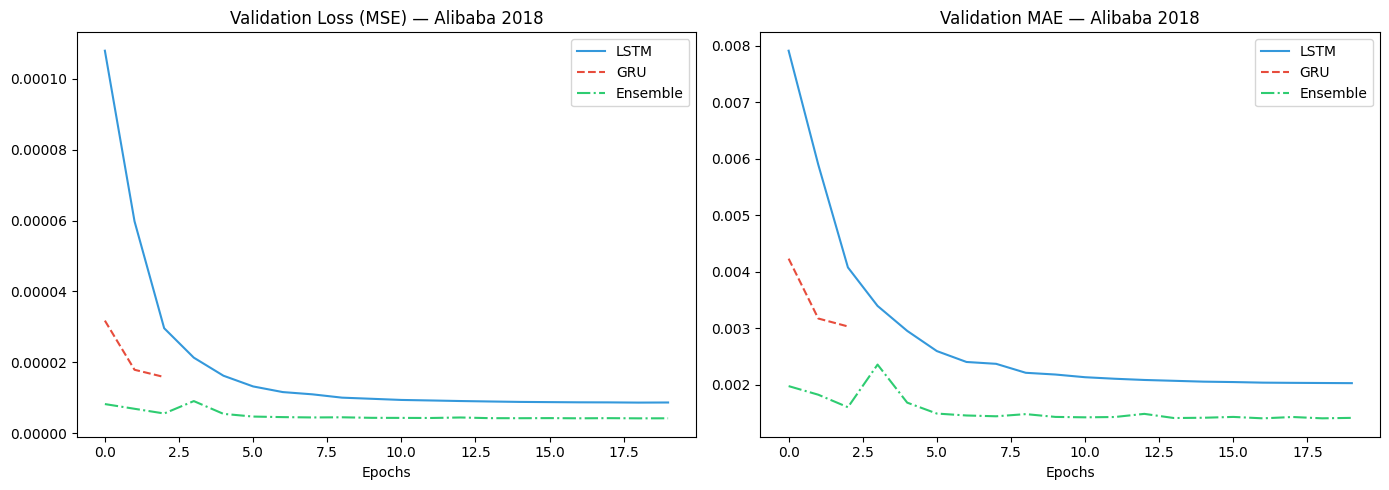

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes, ['val_loss', 'val_mae'], ['Validation Loss (MSE)', 'Validation MAE']):
    ax.plot(lstm_history.history[metric], label='LSTM', color='#3498db')
    ax.plot(gru_history.history[metric],  label='GRU',  color='#e74c3c', linestyle='--')
    ax.plot(ens_history.history[metric],  label='Ensemble', color='#2ecc71', linestyle='-.')
    ax.set_title(f'{title} — Alibaba 2018')
    ax.set_xlabel('Epochs')
    ax.legend()
fig.tight_layout()
plt.savefig('alibaba_training_curves.png', dpi=150)
plt.show()

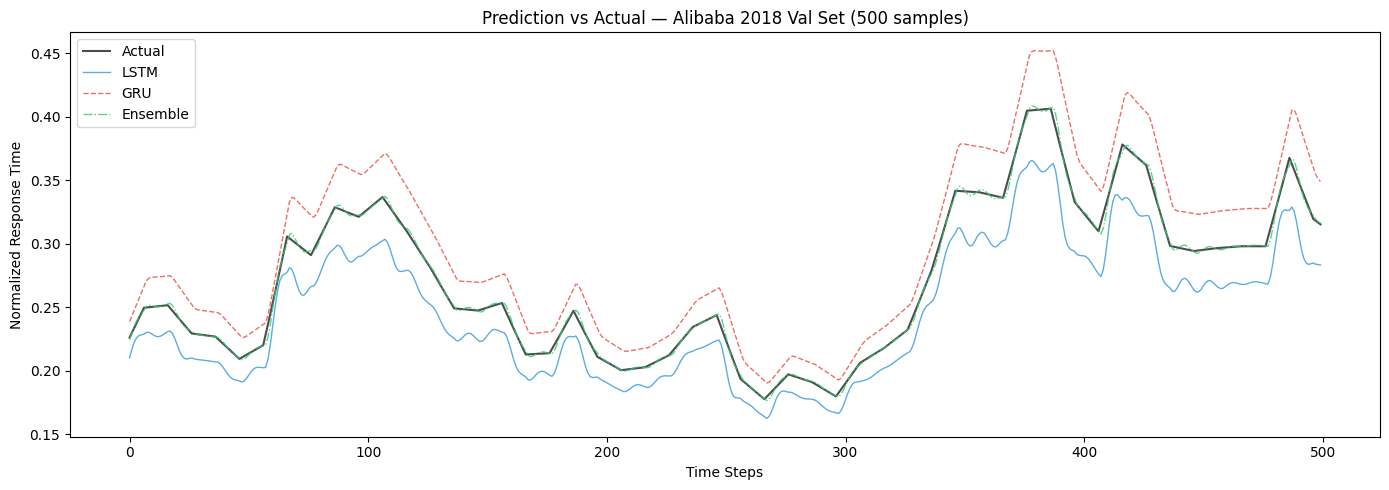

In [13]:
pred_lstm = lstm_model.predict(X_val[:500], verbose=0).flatten()
pred_gru  = gru_model.predict(X_val[:500], verbose=0).flatten()
pred_ens  = ensemble_model.predict(X_val[:500], verbose=0).flatten()
actual    = y_val[:500]

plt.figure(figsize=(14, 5))
plt.plot(actual,    label='Actual',   color='black',   linewidth=1.5, alpha=0.7)
plt.plot(pred_lstm, label='LSTM',     color='#3498db', linewidth=1,   alpha=0.8)
plt.plot(pred_gru,  label='GRU',      color='#e74c3c', linewidth=1,   alpha=0.8, linestyle='--')
plt.plot(pred_ens,  label='Ensemble', color='#2ecc71', linewidth=1,   alpha=0.8, linestyle='-.')
plt.title('Prediction vs Actual — Alibaba 2018 Val Set (500 samples)')
plt.xlabel('Time Steps')
plt.ylabel('Normalized Response Time')
plt.legend()
plt.tight_layout()
plt.savefig('alibaba_prediction_comparison.png', dpi=150)
plt.show()

## 6. 파일 다운로드

In [14]:
import zipfile, os
from google.colab import files

output_files = [
    'lstm_model.keras',
    'gru_model.keras',
    'ensemble_model.keras',
    'alibaba_scaler.pkl',
    'training_summary.csv',
    'alibaba_training_curves.png',
    'alibaba_prediction_comparison.png',
    'alibaba_preview.png',
    'alibaba_feature_preview.png',
]

with zipfile.ZipFile('alibaba_models.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  추가: {f}')
        else:
            print(f'  (없음: {f})')

files.download('alibaba_models.zip')

  추가: lstm_model.keras
  추가: gru_model.keras
  추가: ensemble_model.keras
  추가: alibaba_scaler.pkl
  추가: training_summary.csv
  추가: alibaba_training_curves.png
  추가: alibaba_prediction_comparison.png
  추가: alibaba_preview.png
  추가: alibaba_feature_preview.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. WSL 서버 적용 방법

### 파일 배치
```bash
mkdir -p models/backup_aws
mv models/*.keras models/backup_aws/
mv models/aws_kaggle_scaler.pkl models/backup_aws/

cp alibaba_models/lstm_model.keras     models/
cp alibaba_models/gru_model.keras      models/
cp alibaba_models/ensemble_model.keras models/
cp alibaba_models/alibaba_scaler.pkl   models/
```

### ai_metrics_api.py 수정 2곳

**[1] scaler 파일명:**
```python
# 변경 전
scaler = joblib.load('models/aws_kaggle_scaler.pkl')
# 변경 후
scaler = joblib.load('models/alibaba_scaler.pkl')
```

**[2] look_back 60으로 변경 (필수 — 안하면 shape 에러로 서버 다운):**
```python
# 변경 전
traffic_memory = deque(maxlen=5)
for _ in range(5):
    traffic_memory.append([1, 1, 100.0])
# 변경 후
traffic_memory = deque(maxlen=60)
for _ in range(60):
    traffic_memory.append([1, 1, 100.0])
```